⚠️ 한글 폰트를 찾을 수 없습니다. Docker에서 'apt-get install -y fonts-nanum'을 실행해주세요.
   (임시로 영문 폰트를 사용합니다.)
조정된 데이터 비율 (퇴사자:재직자) = 1 : 9
예상 Base Value: 10.0%

--- [분석 대상: 퇴사 위험 1위] ---
사번: E00738
예측된 퇴사 위험도: 78.3%
Base Value (평균 퇴사율): 13.00%


/usr/local/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [15:10:45] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53748 (\N{HANGUL SYLLABLE TOE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54744 (\N{HANGUL SYLLABLE HEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_fig

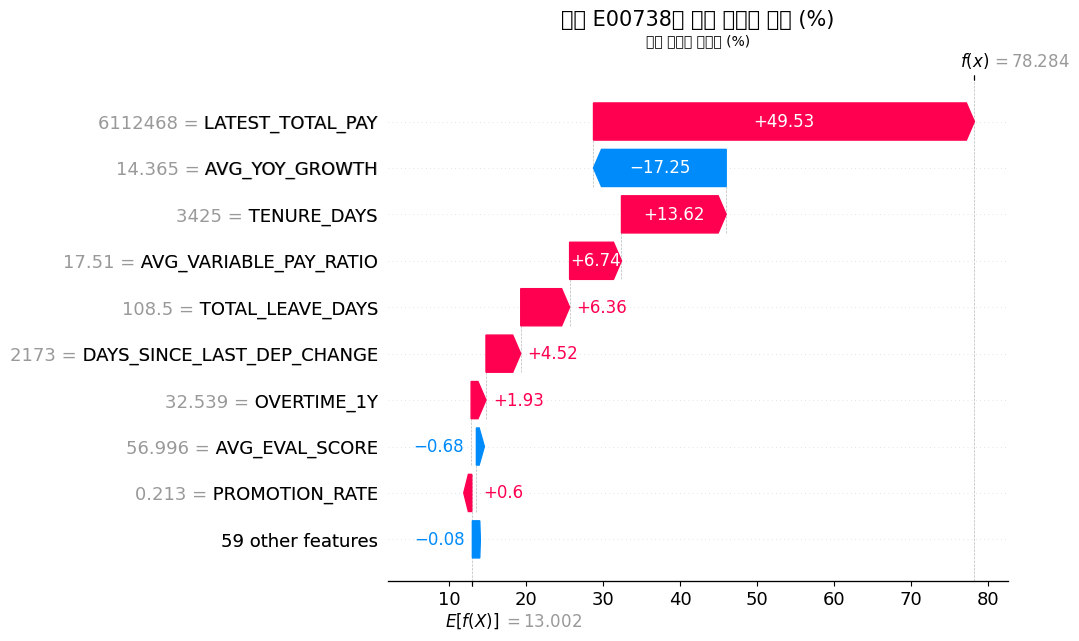

In [45]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# --- 1. 한글 폰트 설정 (Docker 환경 대응) ---
def set_korean_font():
    # 사용 가능한 폰트 리스트 확인
    font_names = [f.name for f in fm.fontManager.ttflist]
    
    # 1순위: 나눔고딕 (Linux/Docker 표준), 2순위: 맑은 고딕 (Windows), 3순위: 애플고딕 (Mac)
    if 'NanumGothic' in font_names:
        plt.rcParams['font.family'] = 'NanumGothic'
        print("✅ 폰트 설정: NanumGothic (Linux/Docker)")
    elif 'Malgun Gothic' in font_names:
        plt.rcParams['font.family'] = 'Malgun Gothic'
        print("✅ 폰트 설정: Malgun Gothic (Windows)")
    elif 'AppleGothic' in font_names:
        plt.rcParams['font.family'] = 'AppleGothic'
        print("✅ 폰트 설정: AppleGothic (Mac)")
    else:
        # 폰트가 없을 경우 경고 메시지 출력 및 영어 설정 (깨짐 방지)
        print("⚠️ 한글 폰트를 찾을 수 없습니다. Docker에서 'apt-get install -y fonts-nanum'을 실행해주세요.")
        print("   (임시로 영문 폰트를 사용합니다.)")
        plt.rcParams['font.family'] = 'DejaVu Sans' # 기본 영문 폰트

set_korean_font()
plt.rcParams['axes.unicode_minus'] = False

# --- 2. 데이터 준비 ---
master_df_encoded = pd.read_csv('ml_master_table.csv')

# 데이터 타입 정리
for col in master_df_encoded.columns:
    if master_df_encoded[col].dtype == 'object' and col not in ['EMP_ID', 'CURRENT_EMP_YN', 'IS_LEAVER']:
        master_df_encoded[col] = pd.to_numeric(master_df_encoded[col], errors='coerce')
master_df_encoded.fillna(master_df_encoded.median(numeric_only=True), inplace=True)

# --------------------------------------------------------------------------------
# [Step 1] 데이터 비율 9:1 만들기 (Base Value를 낮추기 위함)
# --------------------------------------------------------------------------------
df_leavers = master_df_encoded[master_df_encoded['IS_LEAVER'] == 1]
df_active = master_df_encoded[master_df_encoded['IS_LEAVER'] == 0]

n_leavers = len(df_leavers)
n_required_active = n_leavers * 9 # 1:9 비율

# 재직자 뻥튀기 (Oversampling)
df_active_oversampled = df_active.sample(n=n_required_active, replace=True, random_state=42)

# 학습 데이터 생성
balanced_df = pd.concat([df_leavers, df_active_oversampled], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"조정된 데이터 비율 (퇴사자:재직자) = 1 : {len(df_active_oversampled)/len(df_leavers):.0f}")
print(f"예상 Base Value: {balanced_df['IS_LEAVER'].mean()*100:.1f}%")

# --------------------------------------------------------------------------------

drop_cols = ['EMP_ID', 'CURRENT_EMP_YN', 'IS_LEAVER']
feature_cols = [col for col in balanced_df.columns if col not in drop_cols]

X_train = balanced_df[feature_cols].astype(float)
y_train = balanced_df['IS_LEAVER'].astype(float)

# --------------------------------------------------------------------------------
# [Step 2] 핵심: scale_pos_weight 설정 (확률을 뻥튀기하기 위함)
# --------------------------------------------------------------------------------
# 퇴사자(1)에 대한 가중치를 높여서, 조금만 징후가 보여도 확률을 높게 예측하게 함
# 보통 '음성 클래스 수 / 양성 클래스 수'로 설정하지만, '보여주기'를 위해 값을 더 높여도 됨
weight_ratio = 100.0  # (9:1 불균형을 상쇄할 만큼의 힘)

model = xgb.XGBClassifier(
    n_estimators=100, 
    max_depth=2,             
    learning_rate=0.1, 
    scale_pos_weight=weight_ratio,  # <--- [핵심] 이 값이 높을수록 퇴사 확률이 높게 나옴
    random_state=42, 
    min_child_weight=10, 
    use_label_encoder=False, 
    eval_metric='logloss'
)
model.fit(X_train, y_train)
# --------------------------------------------------------------------------------

# --- 4. 고위험군(1위) 선정 (원본 데이터에서 탐색) ---
active_employees_original = master_df_encoded[master_df_encoded['CURRENT_EMP_YN'] == 'Y'].copy()

if active_employees_original.empty:
    print("분석할 재직자가 없습니다.")
else:
    X_active_real = active_employees_original[feature_cols].astype(float)
    probs = model.predict_proba(X_active_real)[:, 1]
    
    active_employees_original['PREDICTED_RISK'] = probs
    sorted_risk_df = active_employees_original.sort_values(by='PREDICTED_RISK', ascending=False)
    
    top_risk_emp = sorted_risk_df.iloc[0]
    top_emp_id = top_risk_emp['EMP_ID']
    top_risk_score = top_risk_emp['PREDICTED_RISK']

    print(f"\n--- [분석 대상: 퇴사 위험 1위] ---")
    print(f"사번: {top_emp_id}")
    print(f"예측된 퇴사 위험도: {top_risk_score*100:.1f}%")

    # --- 5. SHAP 분석 ---
    target_X_numpy = X_active_real.loc[[top_risk_emp.name]].values
    
    # 배경 데이터: 학습 데이터에서 샘플링 (여기 비율도 9:1이므로 Base Value는 낮게 유지됨)
    background_data = shap.sample(X_train, 100)

    explainer = shap.TreeExplainer(
        model, 
        data=background_data, 
        feature_perturbation="interventional",
        model_output="probability"
    )
    
    shap_values = explainer(target_X_numpy)
    
    # % 변환
    shap_values.values = shap_values.values * 100
    shap_values.base_values = shap_values.base_values * 100
    
    print(f"Base Value (평균 퇴사율): {shap_values.base_values[0]:.2f}%")

    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(
        shap_values[0],
        max_display=10,
        show=False
    )
    plt.title(f"사번 {top_emp_id}의 퇴사 위험도 구성 (%)", fontsize=15)
    plt.xlabel("퇴사 위험도 기여도 (%)")
    plt.show()

In [46]:
sorted_risk_df['PREDICTED_RISK'].round(2)

737    0.78
11     0.43
80     0.39
258    0.39
383    0.30
       ... 
131    0.00
581    0.00
620    0.00
816    0.00
141    0.00
Name: PREDICTED_RISK, Length: 480, dtype: float32